In [25]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

# Step 2 Ml processing 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder # for l
from sklearn.utils import shuffle
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [5]:
data = pd.read_csv('/home/susan/Feature_Engineering_Sprint_9/Data/travel_insurance_us_preprocessed.csv')
print(data.info())
print()
print('================'*10)
print(data.columns)
print()
print('================'*10)
target =data['Claim']
features =data.drop('Claim',axis= 1)
X_train, X_valid, y_train, y_valid = train_test_split(features, target, test_size= 0.25, random_state=12345)
model = LogisticRegression(random_state= 12345, solver= 'liblinear',class_weight='balanced')
# A solver is the algorithm
#  that the model uses to find the best parameters (weights) during training.
model.fit(X_train, y_train)
predicted_valid = model.predict(X_valid)
print('F1:', f1_score(y_valid, predicted_valid))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50660 entries, 0 to 50659
Columns: 198 entries, Unnamed: 0 to Gender_None
dtypes: float64(4), int64(194)
memory usage: 76.5 MB
None

Index(['Unnamed: 0', 'Claim', 'Duration', 'Net Sales', 'Commission (in value)',
       'Age', 'Agency_ART', 'Agency_C2B', 'Agency_CBH', 'Agency_CCR',
       ...
       'Destination_URUGUAY', 'Destination_UZBEKISTAN', 'Destination_VANUATU',
       'Destination_VENEZUELA', 'Destination_VIET NAM',
       'Destination_VIRGIN ISLANDS, U.S.', 'Destination_ZAMBIA',
       'Destination_ZIMBABWE', 'Gender_M', 'Gender_None'],
      dtype='object', length=198)

F1: 0.08667152221412965


#### Task1
 Split the training samples into negative and positive observations; declare four variables and store the information in them as follows:

features_zeros — features of the "0" answer observations
features_ones — features of the "1" answer observations
target_zeros — target of the "0" answer observations
target_ones — target of the "1" answer observations
Print the sizes of all four tables stored in the variables (already in the precode).

In [6]:
#This line properly filters the target training data to get only 
#the observations where the target value equals 0. 
# You're using #boolean indexing correctly here.
features_zeros= X_train[y_train==0]
features_ones =X_train[y_train ==1]
target_zeros= y_train[y_train==0]
target_ones =y_train[y_train ==1]
print(features_zeros.shape)
print(features_ones.shape)
print(target_zeros.shape)
print(target_ones.shape)


(37411, 197)
(584, 197)
(37411,)
(584,)


### Task2

2.Duplicate the positive class observations and combine them with the negative class observations. Use the pd.concat() function to concatenate the tables.

To give you an idea of how this works, we upsampled the training features and concatenated them to the original ones. Upsampled training features are stored as the features_upsampled variable in the precode. Repeat the same process for the target column and store the new targets to the target_upsampled variable.

The number of repetitions to be performed for duplications is stored in the repeat variable.

Print the sizes of the new variables (in precode)

In [7]:
# ...existing code...
features_zeros = X_train[y_train == 0]
features_ones = X_train[y_train == 1]
target_zeros = y_train[y_train == 0]
target_ones = y_train[y_train == 1]

repeat = 10
features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

print(features_upsampled.shape)
print(target_upsampled.shape)


(43251, 197)
(43251,)


### Task3.

The next step is to shuffle the data. We can do it using the shuffle() function from the sklearn.utils module.

Your goal now is to write the upsample() function and expect three arguments:

features
target
repeat
The function should return the features and target after upsampling and shuffling. When shuffling, don't forget to specify the random_state parameter. Set it equal to 12345.

Call the function for the training data. Print the sizes of the samples (in precode).

In [8]:
# Upsampling function
# Use this on the training data only, after train_test_split and before model.fit().
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )

    return features_upsampled, target_upsampled

# Then call the function for the training set only.
features_upsampled, target_upsampled = upsample(X_train, y_train, 10)

print(features_upsampled.shape)
print(target_upsampled.shape)

(43251, 197)
(43251,)


### Task4.

Train the LogisticRegression model with the new data. Find the F1 score and print it on the screen (in precode).


In [9]:

model = LogisticRegression(random_state= 12345, solver= 'liblinear')
model.fit(features_upsampled, target_upsampled)
predicted_valid =model.predict(X_valid)
print("F1:", f1_score(y_valid, predicted_valid))


F1: 0.15327102803738318


### Downsampling
##### Task5
To perform downsampling, write a downsample() function that expects three arguments:

features
target
fraction (the fraction of negative observations to keep)
The function will return the features and target after downsampling.

Call the function for the training data with a fraction of 0.1, then print the sizes of samples (in precode).

In [10]:
target = data['Claim']
features = data.drop('Claim', axis=1)
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=12345
)

def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]
    features_downsampled = pd.concat([
    features_zeros.sample(frac=fraction, random_state=12345),  # Take fraction of zeros
    features_ones  # Keep all ones
]) 
    target_downsampled = pd.concat([
    target_zeros.sample(frac=fraction, random_state=12345),  # Take fraction of zeros
    target_ones  # Keep all ones
]) 
    features_downsampled, target_downsampled = shuffle(features_downsampled,target_downsampled,random_state=12345)

    return features_downsampled, target_downsampled

features_downsampled, target_downsampled = downsample(
    features_train, target_train, 0.1
)

print(features_downsampled.shape)
print(target_downsampled.shape)

(4325, 197)
(4325,)


### Task 6

Train the LogisticRegression model with the new data. Find the F1 score and print it on the screen (in precode).

In [13]:
target = data['Claim']
features = data.drop('Claim', axis=1)
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=12345
)

def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat(
        [features_zeros.sample(frac=fraction, random_state=12345)]
        + [features_ones]
    )
    target_downsampled = pd.concat(
        [target_zeros.sample(frac=fraction, random_state=12345)]
        + [target_ones]
    )

    features_downsampled, target_downsampled = shuffle(
        features_downsampled, target_downsampled, random_state=12345
    )

    return features_downsampled, target_downsampled


features_downsampled, target_downsampled = downsample(
    features_train, target_train, 0.1
)

model = LogisticRegression(random_state=12345, solver='liblinear')
model.fit(features_downsampled, target_downsampled)
predicted_valid = model.predict(features_valid)
print('F1:', f1_score(target_valid, predicted_valid))


F1: 0.1482758620689655


### Task 7
Find the class probabilities for the validation samples. Extract the probabilities for the positive class only and store them in the probabilities_one_valid variable. Print the first five elements of this variable (in precode).

In [22]:
target = data['Claim']
features = data.drop('Claim', axis=1)
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=12345
)

model = LogisticRegression(random_state=1, solver='liblinear')
model.fit(features_train, target_train)
# Step 1: Get all probabilities
probabilities_valid = model.predict_proba(features_valid)

# Step 2: Extract only positive class probabilities  
probabilities_one_valid = probabilities_valid[:, 1]
print(probabilities_one_valid[:5])
# Step 2: Extract only negative class probabilities  
probabilities_zero_valid = probabilities_valid[:, 0]
print()
print(probabilities_zero_valid)



[0.01734508 0.01446924 0.00744545 0.00922923 0.01195362]

[0.98265492 0.98553076 0.99255455 ... 0.98777325 0.99217589 0.97718027]


### Task 8
Go through threshold values from 0 to 0.3 in steps of 0.02. Find precision and recall for each threshold value. Print the results (in precode).

To create a loop with the desired range, we use the arange() function from the numpy library. Just like the range() function, it iterates over the specified elements of the range, but it's different in that it works with fractional numbers in addition to integers.

In [19]:
target = data['Claim']
features = data.drop('Claim', axis=1)
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=12345
)

model = LogisticRegression(random_state=12345, solver='liblinear')
model.fit(features_train, target_train)
probabilities_valid = model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
print(probabilities_valid)
print(probabilities_one_valid)

for threshold in np.arange(0,0.3, 0.02):
    probabilities_one_valid>threshold
    precision = precision_score(target_valid,predicted_valid)
    recall = recall_score(target_valid, predicted_valid)
    print('Threshold = {:.2f} | Precision = {:.3f}, ' \
    'Recall = {:.3f}'.format(threshold, precision, recall))







[[0.98265492 0.01734508]
 [0.98553076 0.01446924]
 [0.99255455 0.00744545]
 ...
 [0.98777325 0.01222675]
 [0.99217589 0.00782411]
 [0.97718027 0.02281973]]
[0.01734508 0.01446924 0.00744545 ... 0.01222675 0.00782411 0.02281973]
Threshold = 0.00 | Precision = 0.105, Recall = 0.254
Threshold = 0.02 | Precision = 0.105, Recall = 0.254
Threshold = 0.04 | Precision = 0.105, Recall = 0.254
Threshold = 0.06 | Precision = 0.105, Recall = 0.254
Threshold = 0.08 | Precision = 0.105, Recall = 0.254
Threshold = 0.10 | Precision = 0.105, Recall = 0.254
Threshold = 0.12 | Precision = 0.105, Recall = 0.254
Threshold = 0.14 | Precision = 0.105, Recall = 0.254
Threshold = 0.16 | Precision = 0.105, Recall = 0.254
Threshold = 0.18 | Precision = 0.105, Recall = 0.254
Threshold = 0.20 | Precision = 0.105, Recall = 0.254
Threshold = 0.22 | Precision = 0.105, Recall = 0.254
Threshold = 0.24 | Precision = 0.105, Recall = 0.254
Threshold = 0.26 | Precision = 0.105, Recall = 0.254
Threshold = 0.28 | Precision =

### Task 9

Make a ROC curve for logistic regression and plot it on the graph. Use the instruction in the precode.

We added the random model ROC curve to the precode as well.


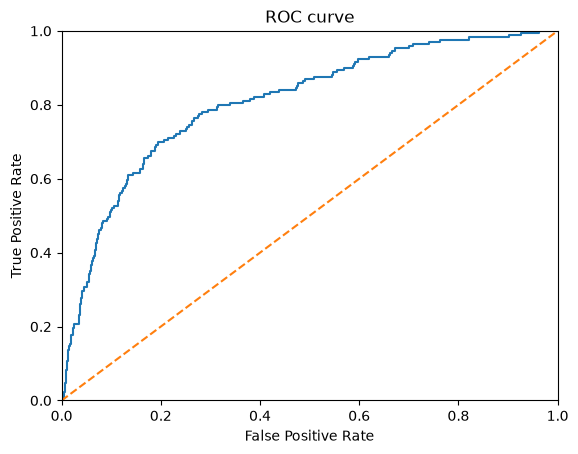

In [24]:
target = data['Claim']
features = data.drop('Claim', axis=1)
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=12345
)

model = LogisticRegression(random_state=12345, solver='liblinear')
model.fit(features_train, target_train)

probabilities_valid = model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid,probabilities_one_valid )

plt.figure()

# < plot the graph >
plt.plot(fpr, tpr)
# ROC curve for random model (looks like a straight line)
plt.plot([0, 1], [0, 1], linestyle='--')

# < use the functions set the boundary for the axes from 0 to 1 >
plt.xlim([0.0, 1.0]) 
plt.ylim([0.0,1.0]) 

# < use the functions plt.xlabel() and plt.ylabel() to
#  name the axes "False Positive Rate" and "True Positive Rate" >
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# < add the heading "ROC curve" with the function plt.title() >
plt.title( "ROC curve")
plt.show()


That plot is a ROC curve for  logistic regression model on the validation set.

What it shows:

* X-axis is False Positive Rate.
* Y-axis is True Positive Rate (recall).
* Each point on the curve is a different classification threshold.
* The dashed diagonal line is a random classifier baseline.

How to read it:

If  ROC curve stays well above the diagonal, the model separates classes better than random.
If it is close to the diagonal, the model has weak discrimination.
The closer the curve gets to the top-left corner, the better.
The summary number for this is AUC-ROC: closer to 1 is better, around 0.5 is random.
In  figure, compare  solid line to the dashed line:

Mostly above dashed line means useful model.
Slightly above means only modest predictive power.

### Task 10
Calculate AUC-ROC for logistic regression. Find the appropriate function in the sklearn documentation, as well as the description of how it works. Import the function. Print the AUC-ROC value on the screen.

In [26]:
target = data['Claim']
features = data.drop('Claim', axis=1)
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.25, random_state=12345
)

model = LogisticRegression(random_state=12345, solver='liblinear')
model.fit(features_train, target_train)
# < write code here >
probabilities_valid = model.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)
auc_roc = roc_auc_score(target_valid, probabilities_one_valid)

print(auc_roc)

0.8074512838191062
